In [1]:
import os
import json
from pathlib import Path
from PIL import Image
from tqdm import tqdm

# ==========================
# CONFIG
# ==========================
TACO_JSON = "/kaggle/input/datasets/kneroma/tacotrashdataset/data/annotations.json"
IMAGE_DIR = "taco/images"
OUTPUT_DIR = "/kaggle/working/taco_cls"
TACO_ROOT = "/kaggle/input/datasets/kneroma/tacotrashdataset/data"
# Map TACO categories -> your 10 classes
CLASS_MAPPING = {
    # ==========================================
    # BATTERY
    # ==========================================
    "Battery": "battery",

    # ==========================================
    # BIOLOGICAL
    # ==========================================
    "Food waste": "biological",

    # ==========================================
    # CARDBOARD
    # ==========================================
    "Carded blister pack": "cardboard",
    "Toilet tube": "cardboard",
    "Other carton": "cardboard",
    "Egg carton": "cardboard",
    "Drink carton": "cardboard",
    "Corrugated carton": "cardboard",
    "Meal carton": "cardboard",
    "Pizza box": "cardboard",
    "Paper bag": "cardboard",

    # ==========================================
    # CLOTHES
    # ==========================================
    "Rope & strings": "clothes",
    "Plastic glooves": "clothes",

    # ==========================================
    # GLASS
    # ==========================================
    "Glass bottle": "glass",
    "Broken glass": "glass",
    "Glass jar": "glass",
    "Glass cup": "glass",

    # ==========================================
    # METAL
    # ==========================================
    "Aluminium foil": "metal",
    "Aluminium blister pack": "metal",
    "Metal bottle cap": "metal",
    "Food Can": "metal",
    "Aerosol": "metal",
    "Drink can": "metal",
    "Metal lid": "metal",
    "Pop tab": "metal",
    "Scrap metal": "metal",

    # ==========================================
    # PAPER
    # ==========================================
    "Paper cup": "paper",
    "Magazine paper": "paper",
    "Tissues": "paper",
    "Wrapping paper": "paper",
    "Normal paper": "paper",
    "Paper straw": "paper",

    # ==========================================
    # PLASTIC
    # ==========================================
    "Other plastic bottle": "plastic",
    "Clear plastic bottle": "plastic",
    "Plastic bottle cap": "plastic",
    "Plastic lid": "plastic",
    "Other plastic": "plastic",
    "Plastic film": "plastic",
    "Six pack rings": "plastic",
    "Garbage bag": "plastic",
    "Other plastic wrapper": "plastic",
    "Single-use carrier bag": "plastic",
    "Polypropylene bag": "plastic",
    "Crisp packet": "plastic",
    "Spread tub": "plastic",
    "Tupperware": "plastic",
    "Disposable food container": "plastic",
    "Other plastic container": "plastic",
    "Disposable plastic cup": "plastic",
    "Other plastic cup": "plastic",
    "Plastic utensils": "plastic",
    "Squeezable tube": "plastic",
    "Plastic straw": "plastic",

    # ==========================================
    # SHOES
    # ==========================================
    "Shoe": "shoes",

    # ==========================================
    # TRASH / NON-RECYCLABLE
    # ==========================================
    "Foam cup": "trash",
    "Foam food container": "trash",
    "Styrofoam piece": "trash",
    "Plastified paper bag": "trash",
    "Plastic glooves": "trash",   # optional: choose clothes OR trash
    "Unlabeled litter": "trash",
    "Cigarette": "trash"
}
# ==========================
# CREATE OUTPUT FOLDERS
# ==========================
for cls in set(CLASS_MAPPING.values()):
    os.makedirs(os.path.join(OUTPUT_DIR, cls), exist_ok=True)

# ==========================
# LOAD ANNOTATIONS
# ==========================
with open(TACO_JSON, "r") as f:
    data = json.load(f)

images = {img["id"]: img for img in data["images"]}
categories = {cat["id"]: cat["name"] for cat in data["categories"]}

# ==========================
# CROP OBJECTS
# ==========================
count = 0

for ann in tqdm(data["annotations"]):
    image_id = ann["image_id"]
    category_name = categories[ann["category_id"]]

    if category_name not in CLASS_MAPPING:
        continue

    target_class = CLASS_MAPPING[category_name]

    img_info = images[image_id]
    

    img_path = None
    for path in Path(TACO_ROOT).rglob(img_info["file_name"]):
        img_path = str(path)
        break
    
    if img_path is None:
        continue
    
    if not os.path.exists(img_path):
        continue

    try:
        img = Image.open(img_path).convert("RGB")

        x, y, w, h = ann["bbox"]
        x1, y1 = int(x), int(y)
        x2, y2 = int(x + w), int(y + h)

        crop = img.crop((x1, y1, x2, y2))

        # Skip tiny objects
        if crop.size[0] < 32 or crop.size[1] < 32:
            continue

        save_name = f"{Path(img_info['file_name']).stem}_{ann['id']}.jpg"
        save_path = os.path.join(OUTPUT_DIR, target_class, save_name)

        crop.save(save_path)
        count += 1

    except Exception as e:
        print(f"Error processing {img_path}: {e}")

print(f"\nDone! Saved {count} cropped images.")
print(f"Dataset saved to: {OUTPUT_DIR}")


100%|██████████| 4784/4784 [06:41<00:00, 11.91it/s]


Done! Saved 4134 cropped images.
Dataset saved to: /kaggle/working/taco_cls


In [2]:
import os
import shutil
from pathlib import Path
from tqdm import tqdm

# ==========================================
# PATHS
# ==========================================
TACO_DIR = "/kaggle/working/taco_cls"
ORIGINAL_DIR = "/kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_384"
MERGED_DIR = "/kaggle/working/final_cls_dataset"

# ==========================================
# CREATE OUTPUT DIRECTORY
# ==========================================
os.makedirs(MERGED_DIR, exist_ok=True)

# 10 target classes
CLASSES = [
    "battery",
    "biological",
    "cardboard",
    "clothes",
    "glass",
    "metal",
    "paper",
    "plastic",
    "shoes",
    "trash"
]

for cls in CLASSES:
    os.makedirs(os.path.join(MERGED_DIR, cls), exist_ok=True)

# ==========================================
# COPY ORIGINAL DATASET
# ==========================================
print("Copying original dataset...")

for cls in CLASSES:
    src_dir = os.path.join(ORIGINAL_DIR, cls)
    dst_dir = os.path.join(MERGED_DIR, cls)

    if not os.path.exists(src_dir):
        print(f"Warning: {cls} not found in original dataset")
        continue

    for img_path in tqdm(list(Path(src_dir).glob("*")), desc=f"Original - {cls}"):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        new_name = f"orig_{img_path.name}"
        shutil.copy2(img_path, os.path.join(dst_dir, new_name))

# ==========================================
# COPY TACO DATASET
# ==========================================
print("\nCopying TACO dataset...")

for cls in CLASSES:
    src_dir = os.path.join(TACO_DIR, cls)
    dst_dir = os.path.join(MERGED_DIR, cls)

    if not os.path.exists(src_dir):
        continue

    for img_path in tqdm(list(Path(src_dir).glob("*")), desc=f"TACO - {cls}"):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        new_name = f"taco_{img_path.name}"
        shutil.copy2(img_path, os.path.join(dst_dir, new_name))

# ==========================================
# SUMMARY
# ==========================================
print("\n" + "=" * 50)
print("FINAL DATASET SUMMARY")
print("=" * 50)

total = 0
for cls in CLASSES:
    cls_dir = os.path.join(MERGED_DIR, cls)
    count = len([
        f for f in os.listdir(cls_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    total += count
    print(f"{cls:12s}: {count:5d}")

print("=" * 50)
print(f"Total Images: {total}")
print(f"Saved to: {MERGED_DIR}")
print("=" * 50)


Copying original dataset...


Original - trash: 100%|██████████| 453/453 [00:04<00:00, 100.65it/s]



Copying TACO dataset...


TACO - trash: 100%|██████████| 885/885 [00:00<00:00, 9244.42it/s]


FINAL DATASET SUMMARY
battery     :   758
biological  :   707
cardboard   :  1689
clothes     :  1921
glass       :  1940
metal       :  1433
paper       :  1553
plastic     :  3598
shoes       :  1456
trash       :  1338
Total Images: 16393
Saved to: /kaggle/working/final_cls_dataset


DATASET SUMMARY
battery     :   758 images ( 4.62%)
biological  :   707 images ( 4.31%)
cardboard   :  1689 images (10.30%)
clothes     :  1921 images (11.72%)
glass       :  1940 images (11.83%)
metal       :  1433 images ( 8.74%)
paper       :  1553 images ( 9.47%)
plastic     :  3598 images (21.95%)
shoes       :  1456 images ( 8.88%)
trash       :  1338 images ( 8.16%)
Total Images: 16393
Total Classes: 10

Classes with fewer than 100 images:


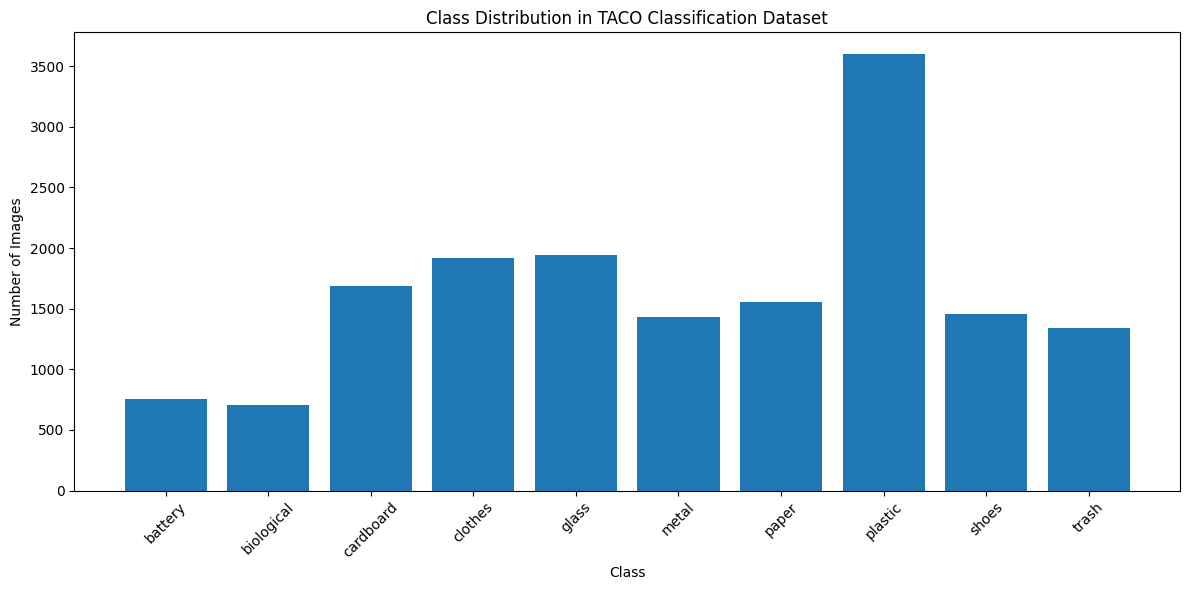

In [4]:
import os
from collections import defaultdict
import matplotlib.pyplot as plt

DATASET_DIR = "/kaggle/working/final_cls_dataset"

# ==========================
# COUNT IMAGES PER CLASS
# ==========================
class_counts = {}

for class_name in sorted(os.listdir(DATASET_DIR)):
    class_path = os.path.join(DATASET_DIR, class_name)

    if os.path.isdir(class_path):
        num_images = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        class_counts[class_name] = num_images

# ==========================
# PRINT SUMMARY
# ==========================
print("=" * 40)
print("DATASET SUMMARY")
print("=" * 40)

total_images = sum(class_counts.values())

for class_name, count in class_counts.items():
    percentage = (count / total_images) * 100 if total_images > 0 else 0
    print(f"{class_name:12s}: {count:5d} images ({percentage:5.2f}%)")

print("=" * 40)
print(f"Total Images: {total_images}")
print(f"Total Classes: {len(class_counts)}")
print("=" * 40)

# ==========================
# FIND IMBALANCED CLASSES
# ==========================
print("\nClasses with fewer than 100 images:")
for class_name, count in class_counts.items():
    if count < 100:
        print(f"- {class_name}: {count}")

# ==========================
# PLOT DISTRIBUTION
# ==========================
plt.figure(figsize=(12, 6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution in TACO Classification Dataset")
plt.tight_layout()
plt.show()


In [5]:
import os
import random
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

# ==========================================
# CONFIG
# ==========================================
SOURCE_DIR = "/kaggle/working/final_cls_dataset"
OUTPUT_DIR = "/kaggle/working/garbage_split"

TRAIN_RATIO = 0.7
VAL_RATIO = 0.2
TEST_RATIO = 0.1
SEED = 42

random.seed(SEED)

# ==========================================
# CREATE FOLDERS
# ==========================================
splits = ["train", "val", "test"]

classes = sorted([
    d.name for d in Path(SOURCE_DIR).iterdir() if d.is_dir()
])

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)

# ==========================================
# SPLIT DATA
# ==========================================
for cls in classes:
    cls_dir = os.path.join(SOURCE_DIR, cls)

    images = [
        str(p) for p in Path(cls_dir).glob("*")
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]

    if len(images) < 10:
        print(f"Skipping {cls}: too few images")
        continue

    # Train 70%
    train_files, temp_files = train_test_split(
        images,
        test_size=(1 - TRAIN_RATIO),
        random_state=SEED,
        shuffle=True
    )

    # Val 20%, Test 10%
    val_files, test_files = train_test_split(
        temp_files,
        test_size=(TEST_RATIO / (VAL_RATIO + TEST_RATIO)),
        random_state=SEED,
        shuffle=True
    )

    split_map = {
        "train": train_files,
        "val": val_files,
        "test": test_files
    }

    for split, files in split_map.items():
        for file in files:
            dst = os.path.join(
                OUTPUT_DIR,
                split,
                cls,
                Path(file).name
            )
            shutil.copy2(file, dst)

# ==========================================
# SUMMARY
# ==========================================
print("=" * 50)
print("DATASET SPLIT COMPLETE")
print("=" * 50)

for split in splits:
    print(f"\n{split.upper()}:")
    total = 0
    for cls in classes:
        cls_path = os.path.join(OUTPUT_DIR, split, cls)
        count = len(list(Path(cls_path).glob("*")))
        total += count
        print(f"{cls:12s}: {count:5d}")
    print(f"Total {split}: {total}")

print(f"\nSaved to: {OUTPUT_DIR}")


DATASET SPLIT COMPLETE

TRAIN:
battery     :   530
biological  :   494
cardboard   :  1182
clothes     :  1344
glass       :  1357
metal       :  1003
paper       :  1087
plastic     :  2518
shoes       :  1019
trash       :   936
Total train: 11470

VAL:
battery     :   152
biological  :   142
cardboard   :   338
clothes     :   384
glass       :   388
metal       :   286
paper       :   310
plastic     :   720
shoes       :   291
trash       :   268
Total val: 3279

TEST:
battery     :    76
biological  :    71
cardboard   :   169
clothes     :   193
glass       :   195
metal       :   144
paper       :   156
plastic     :   360
shoes       :   146
trash       :   134
Total test: 1644

Saved to: /kaggle/working/garbage_split


In [14]:
import sys
sys.path.append("/kaggle/working/garbage_classification")


config

In [12]:
import os
import torch

DATA_DIR = "/kaggle/working/garbage_split"
MODEL_PATH = "/kaggle/input/models/triuinhhi/garbage-cls/pytorch/default/1/garbage_classifier_final.pth"
SAVE_DIR = "/kaggle/working/checkpoints"

NUM_CLASSES = 10
BATCH_SIZE = 32
IMG_SIZE = 384
NUM_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 8
LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 4
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_GPUS = torch.cuda.device_count()
os.makedirs(SAVE_DIR, exist_ok=True)


data_loader

In [ ]:
import os
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

def get_transforms():
    train_transforms = transforms.Compose([
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.1
        ),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    val_transforms = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    return train_transforms, val_transforms

def get_dataloaders():
    train_tf, val_tf = get_transforms()

    datasets_dict = {
        'train': datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), train_tf),
        'val': datasets.ImageFolder(os.path.join(DATA_DIR, 'val'), val_tf),
        'test': datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), val_tf)
    }

    dataloaders = {
        x: DataLoader(
            datasets_dict[x],
            batch_size=BATCH_SIZE,
            shuffle=(x == 'train'),
            num_workers=NUM_WORKERS,
            pin_memory=True
        ) for x in ['train', 'val', 'test']
    }

    dataset_sizes = {x: len(datasets_dict[x]) for x in datasets_dict}
    class_names = datasets_dict['train'].classes

    return datasets_dict, dataloaders, dataset_sizes, class_names

def get_class_weights(train_dataset):
    labels = [label for _, label in train_dataset.samples]
    counts = np.bincount(labels)
    weights = len(labels) / (len(counts) * counts)
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


model

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

def build_model():
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    if NUM_GPUS > 1:
        print(f"Using {NUM_GPUS} GPUs")
        model = nn.DataParallel(model)

    return model.to(DEVICE)


train

In [ ]:
import copy
class EarlyStopping:
    def __init__(self, patience=8):
        self.patience = patience
        self.counter = 0
        self.best_acc = 0
        self.early_stop = False

    def __call__(self, val_acc):
        if val_acc > self.best_acc:
            self.best_acc = val_acc
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
            return False

def train_model(model, dataloaders, dataset_sizes, criterion,
                optimizer, scheduler, class_names):
    best_model_wts = copy.deepcopy(model.state_dict())
    early_stopping = EarlyStopping(EARLY_STOPPING_PATIENCE)

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    for epoch in range(NUM_EPOCHS):
        print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')
        print('-' * 50)

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase:5s} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val' and early_stopping(epoch_acc.item()):
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save({
                    'epoch': epoch + 1,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_acc': epoch_acc.item(),
                    'class_names': class_names
                }, os.path.join(SAVE_DIR, 'best_resnet50_garbage.pth'))

        if early_stopping.early_stop:
            print(f'Early stopping triggered at epoch {epoch+1}')
            break

    model.load_state_dict(best_model_wts)
    return model, history


evaluate

In [ ]:
import torch
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, dataloader, class_names):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print('\nClassification Report:')
    print(classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    ))

    print('\nConfusion Matrix:')
    print(confusion_matrix(all_labels, all_preds))


main

In [15]:
import time
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler



def main():
    datasets_dict, dataloaders, dataset_sizes, class_names = get_dataloaders()

    print('Classes:', class_names)
    print('Dataset sizes:', dataset_sizes)

    model = build_model()
    class_weights = get_class_weights(datasets_dict['train'])

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    start = time.time()

    model, history = train_model(
        model,
        dataloaders,
        dataset_sizes,
        criterion,
        optimizer,
        scheduler,
        class_names
    )

    print(f'\nTraining completed in {(time.time() - start)/60:.2f} minutes')

    evaluate_model(model, dataloaders['test'], class_names)


if __name__ == '__main__':
    main()


ModuleNotFoundError: No module named 'config'